In [54]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from anndata import AnnData
from scipy.spatial import ConvexHull
import seaborn as sns

In [55]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
#sc.logging.print_versions()

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

from pathlib import Path

# Get the current working directory as a Path object
current_dir = Path.cwd()

# Get the parent directory
parent_dir = current_dir.parent

print(f"Current Directory: {current_dir}")
print(f"Parent Directory: {parent_dir}")

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
# sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current Directory: C:\Users\Gabrielle\Documents\GitHub\ctnnd2_xenium_cell_counting\scripts
Parent Directory: C:\Users\Gabrielle\Documents\GitHub\ctnnd2_xenium_cell_counting


In [56]:
#read in data after batch correction and label transfer
xenium_data_path = "Z:/eroglulab_share/Gabi_Sejourne/Ctnnd2Zbtb20_Manuscript_DevCell_2025/Figure 5 and S4/xenium_dataset/GEO_submission/anndata_objects"
puck = sc.read_h5ad(f'{xenium_data_path}/adata_tacco_xenium_annotFinal.h5ad')

# Filter only desired predicted types
astro_mask = adata_combined.obs['predicted_type'].isin(['Upper', 'Mid', 'Deep_WM'])
puck_astro = adata_combined[astro_mask].copy()

# Define masks for each sample and condition
astro_mask_1M = puck_astro.obs['sample_id'] == '1M_KO'
astro_mask_8M = puck_astro.obs['sample_id'] == '8M_WT'
astro_mask_2F = puck_astro.obs['sample_id'] == '2F_WT'
astro_mask_7F = puck_astro.obs['sample_id'] == '7F_KO'
astro_mask_WT = puck_astro.obs['condition'] == 'WT'
astro_mask_KO = puck_astro.obs['condition'] == 'KO'

# Subset AnnData objects
puck_astro_1M = puck_astro[astro_mask_1M].copy()
puck_astro_8M = puck_astro[astro_mask_8M].copy()
puck_astro_2F = puck_astro[astro_mask_2F].copy()
puck_astro_7F = puck_astro[astro_mask_7F].copy()
puck_astro_WT = puck_astro[astro_mask_WT].copy()
puck_astro_KO = puck_astro[astro_mask_KO].copy()

In [57]:
#define function for computing convex hull and finding distance from top edge

def plot_spatial_boundary_dist_all_cells(adata, adata_name, obs_col='predicted_type', basis='spatial'):
    """
    Calculates distance of a cell adata to its upper convex hull boundary.
    
    Parameters:
    - adata: AnnData object
    - cell_type: String, the specific cell type to filter for
    - adata_name: String, the sample identifier
    - obs_col: The column in adata.obs to filter by
    - basis: The key in adata.obsm containing coordinates
    """

    points = np.array(adata.obsm[basis])

    # 2. Compute the Convex Hull
    hull = ConvexHull(points)

    # 3. Filter for 'Top' edges using the slope constraint
    normals = hull.equations[:, :2]
    # Points UP (B > 0) AND is more horizontal than vertical (|B| > |A|)
    top_mask = (normals[:, 1] > 0) & (np.abs(normals[:, 1]) > np.abs(normals[:, 0]))
    top_edge_indices = np.where(top_mask)[0]
    top_simplices = hull.simplices[top_edge_indices]

    # 4. Define distance helper
    def dist_to_segment(p, a, b):
        pa = p - a
        ba = b - a
        # Use a small epsilon to avoid division by zero for identical points
        denom = np.sum(ba * ba)
        if denom == 0: return np.linalg.norm(pa, axis=1)
        t = np.clip(np.sum(pa * ba, axis=1) / denom, 0, 1)
        closest_points = a + t[:, np.newaxis] * ba
        return np.linalg.norm(p - closest_points, axis=1)

    # 5. Calculate minimum distance to any "top" segment
    min_distances = np.full(len(points), np.inf)
    for simplex in top_simplices:
        p1, p2 = points[simplex[0]], points[simplex[1]]
        dists = dist_to_segment(points, p1, p2)
        min_distances = np.minimum(min_distances, dists)

    # Store distances back in the adata for potential later use
    adata.obs['dist_to_top'] = min_distances

    # 6. Plotting
    plt.figure(figsize=(10, 6))
    
    # Define colors for cell types
    celltype_colors = {
        "Upper": "magenta",
        "Mid": "green",
        "Deep_WM": "cyan"
    }
    
    # Map each cell to a color
    colors = adata.obs[obs_col].map(celltype_colors)

    # Precompute once
    all_points = np.array(adata.obsm[basis])
    
    for cell_type in ["Upper", "Mid", "Deep_WM"]:
        
        subset = adata[adata.obs[obs_col] == cell_type]
        subset_points = np.array(subset.obsm[basis])
    
        plt.figure(figsize=(10, 6))
    
        # Plot only this cell type
        plt.scatter(
            subset_points[:, 0],
            subset_points[:, 1],
            color=celltype_colors.get(cell_type, "gray"),
            s=15,
            zorder=2,
            label=cell_type
        )
    
        # Draw hull using ALL points
        for i, simplex in enumerate(top_simplices):
            label = 'Top Boundary' if i == 0 else ""
            plt.plot(
                all_points[simplex, 0],
                all_points[simplex, 1],
                'r-', linewidth=4, label=label, zorder=5
            )
    
        # Other hull edges
        for simplex in hull.simplices:
            is_top = any(
                np.array_equal(simplex, ts) or np.array_equal(simplex[::-1], ts)
                for ts in top_simplices
            )
            if not is_top:
                plt.plot(
                    all_points[simplex, 0],
                    all_points[simplex, 1],
                    'k--', alpha=0.2
                )
    
        plt.title(f"{cell_type}: Distance to Top Boundary")
        plt.xlabel(f"{basis}_1")
        plt.ylabel(f"{basis}_2")
        plt.legend()
    
        plt.savefig(
            f"{parent_dir}/plots/spatial_scatter_{adata_name}_{cell_type}.png",
            dpi=300
        )
        plt.show()
        
    return adata # Optional: return the subset with the new distance column

<Figure size 800x480 with 0 Axes>

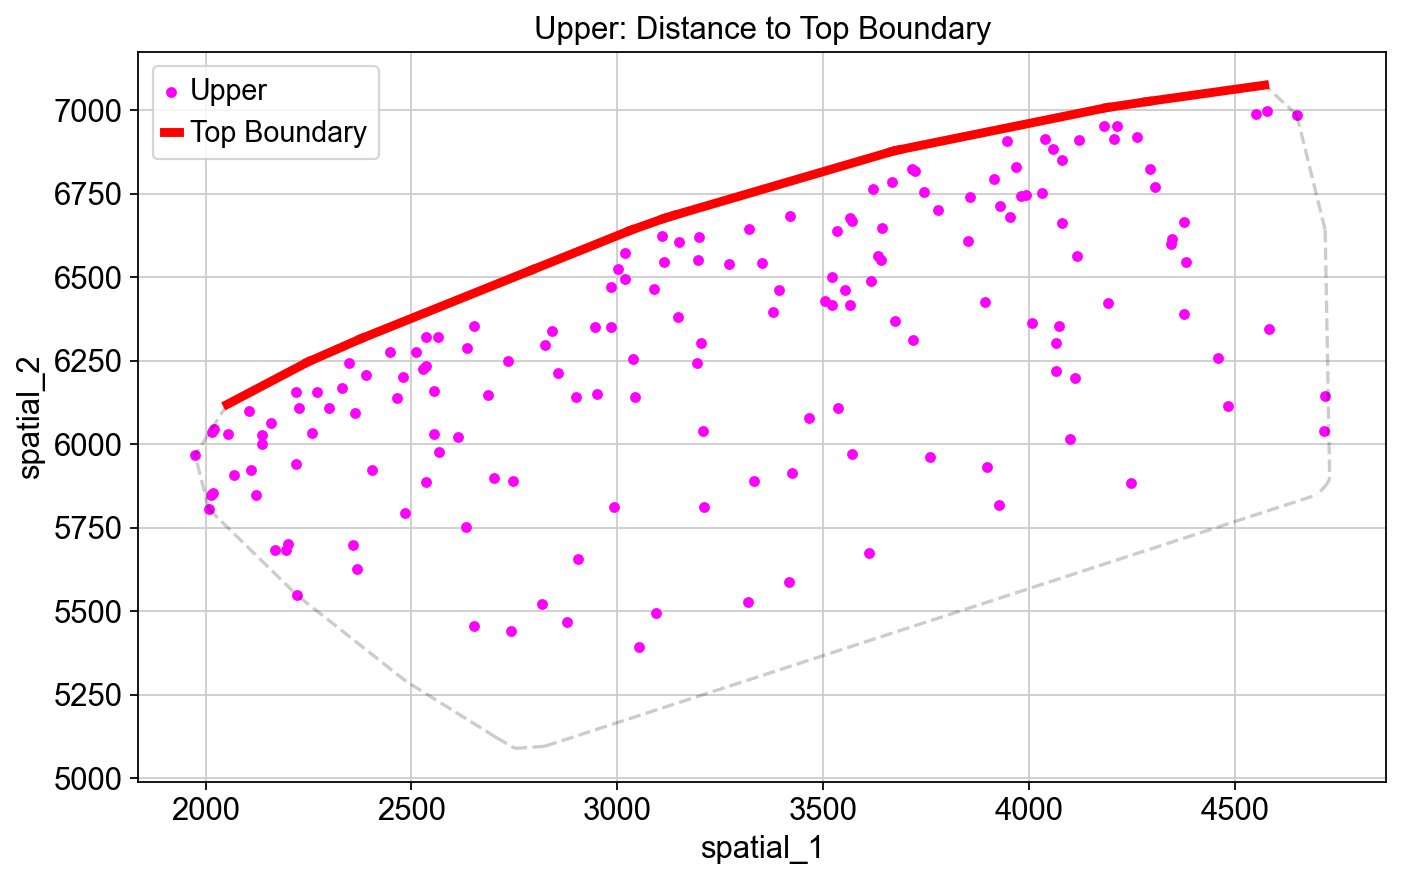

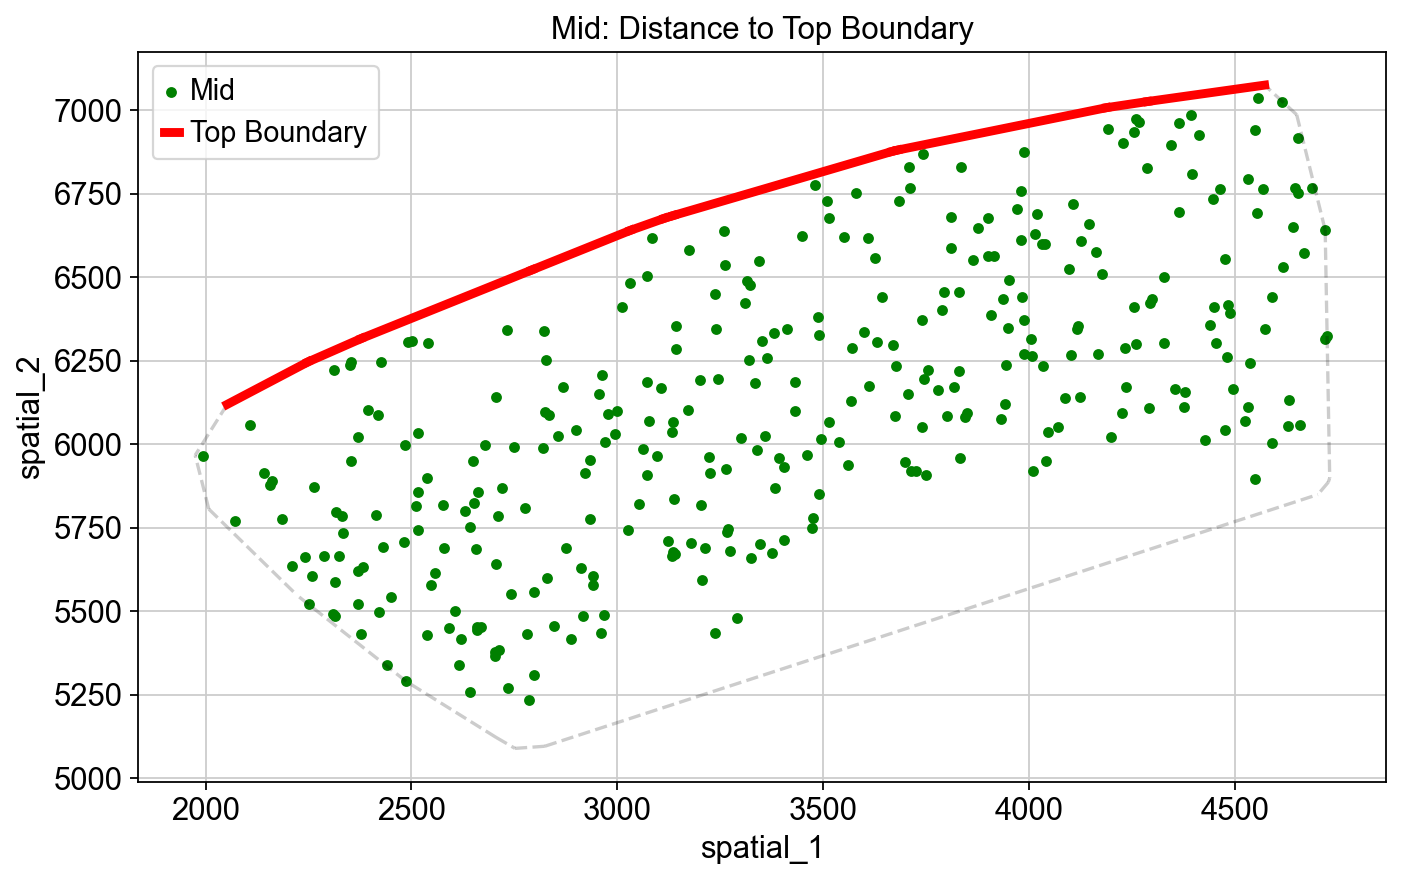

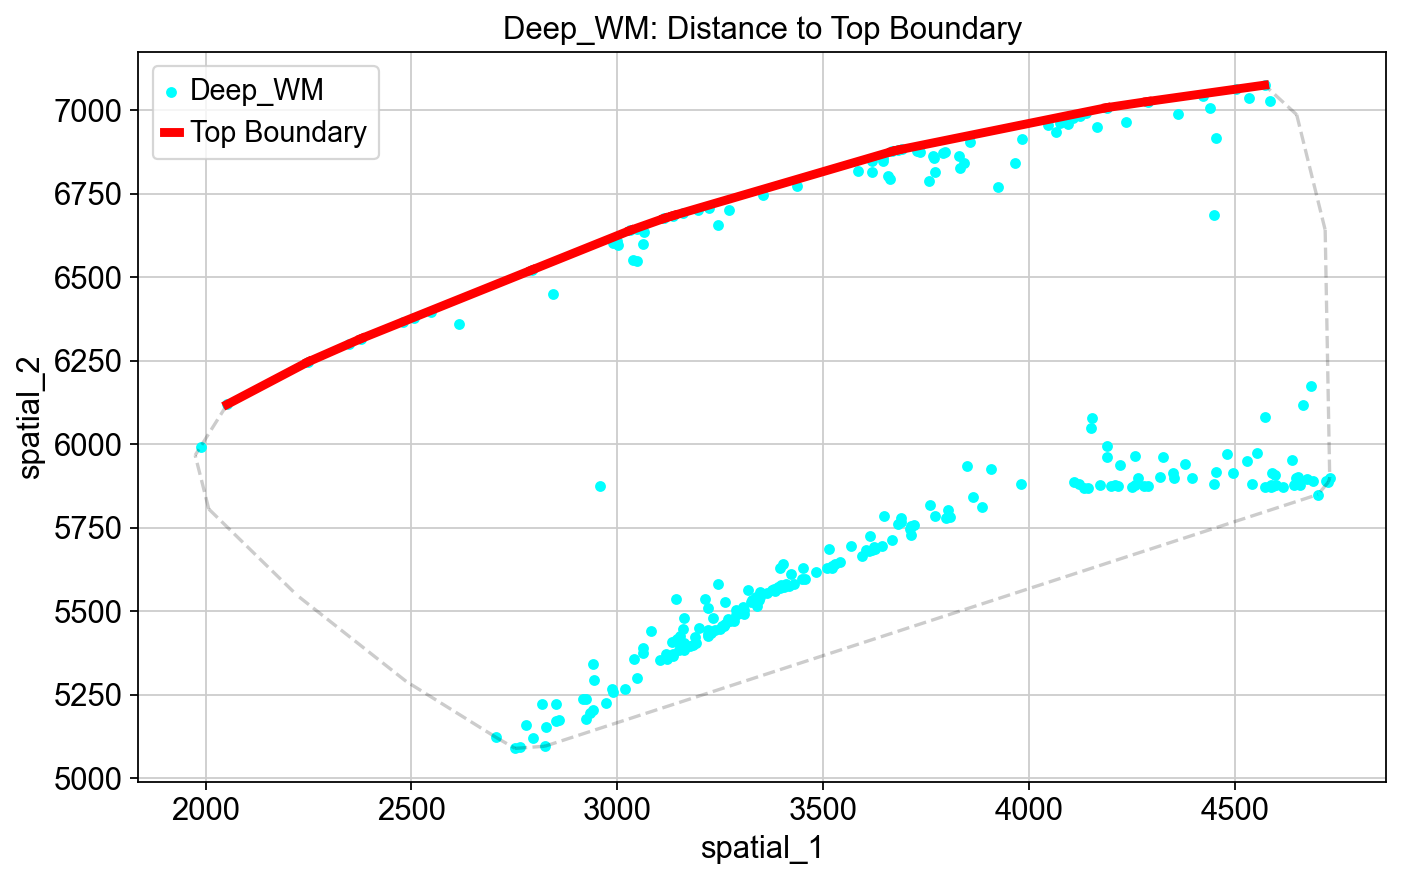

<Figure size 800x480 with 0 Axes>

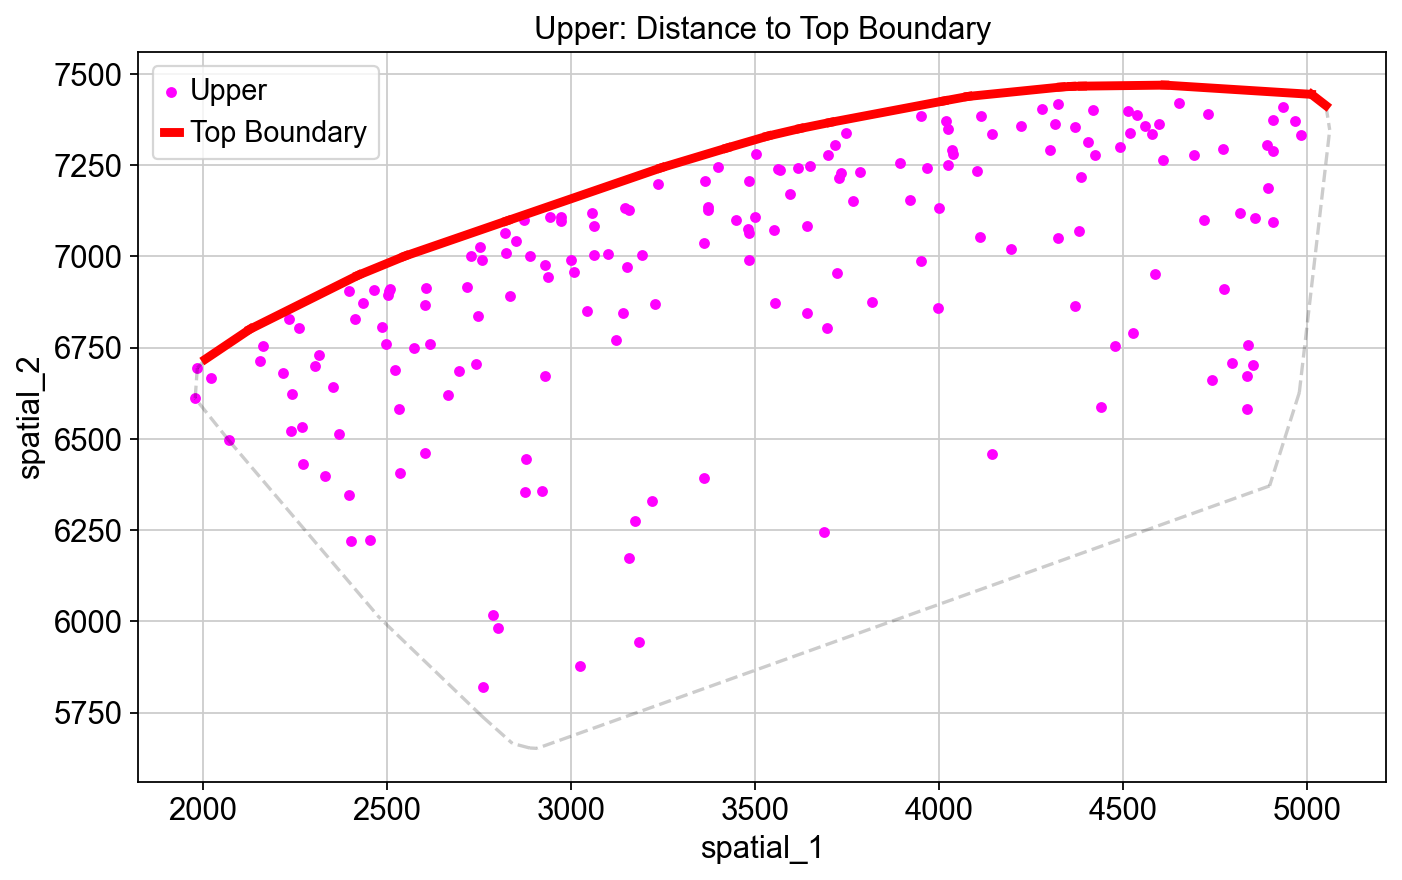

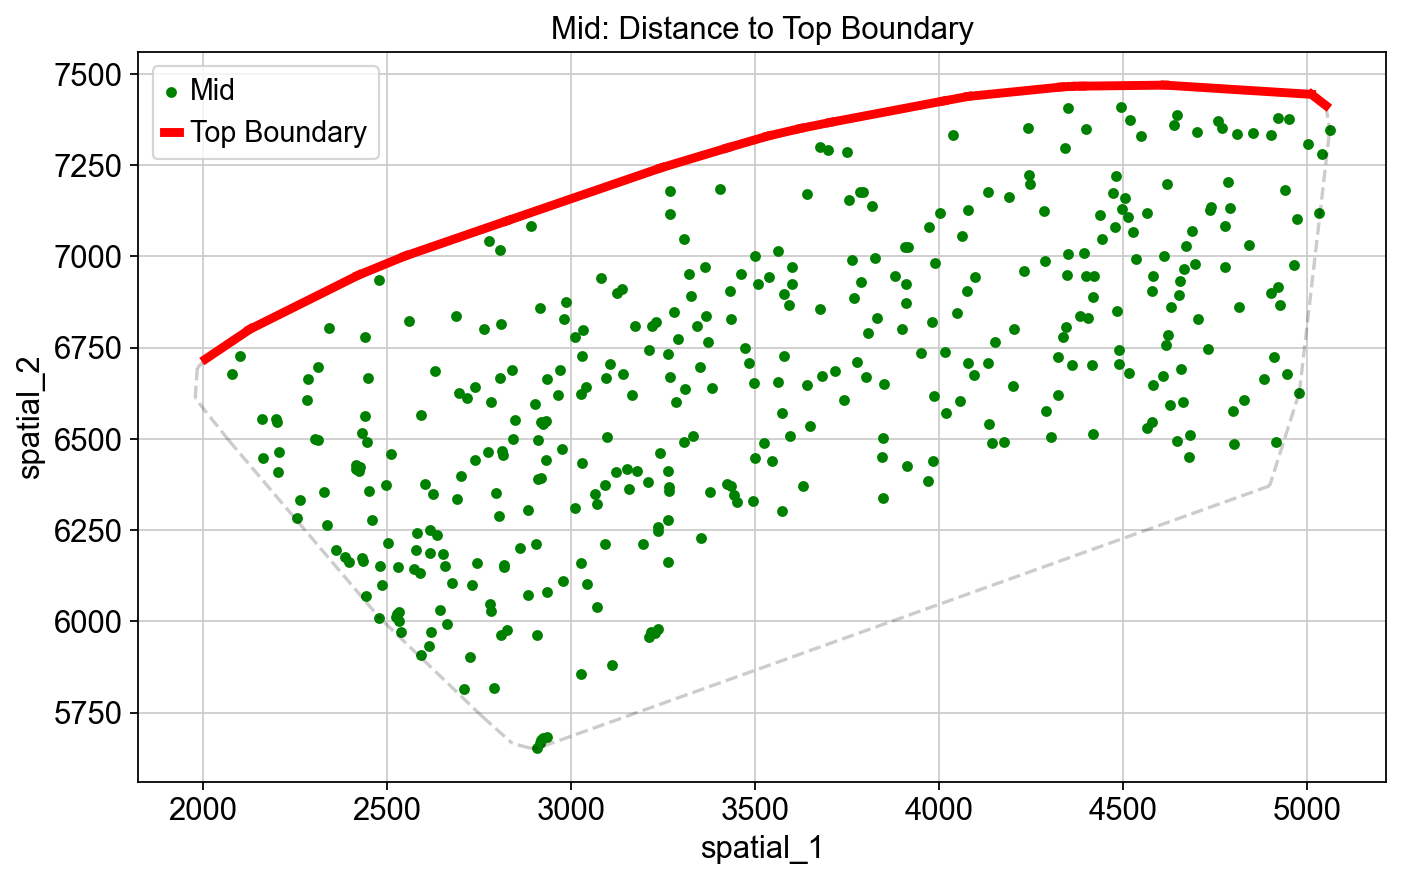

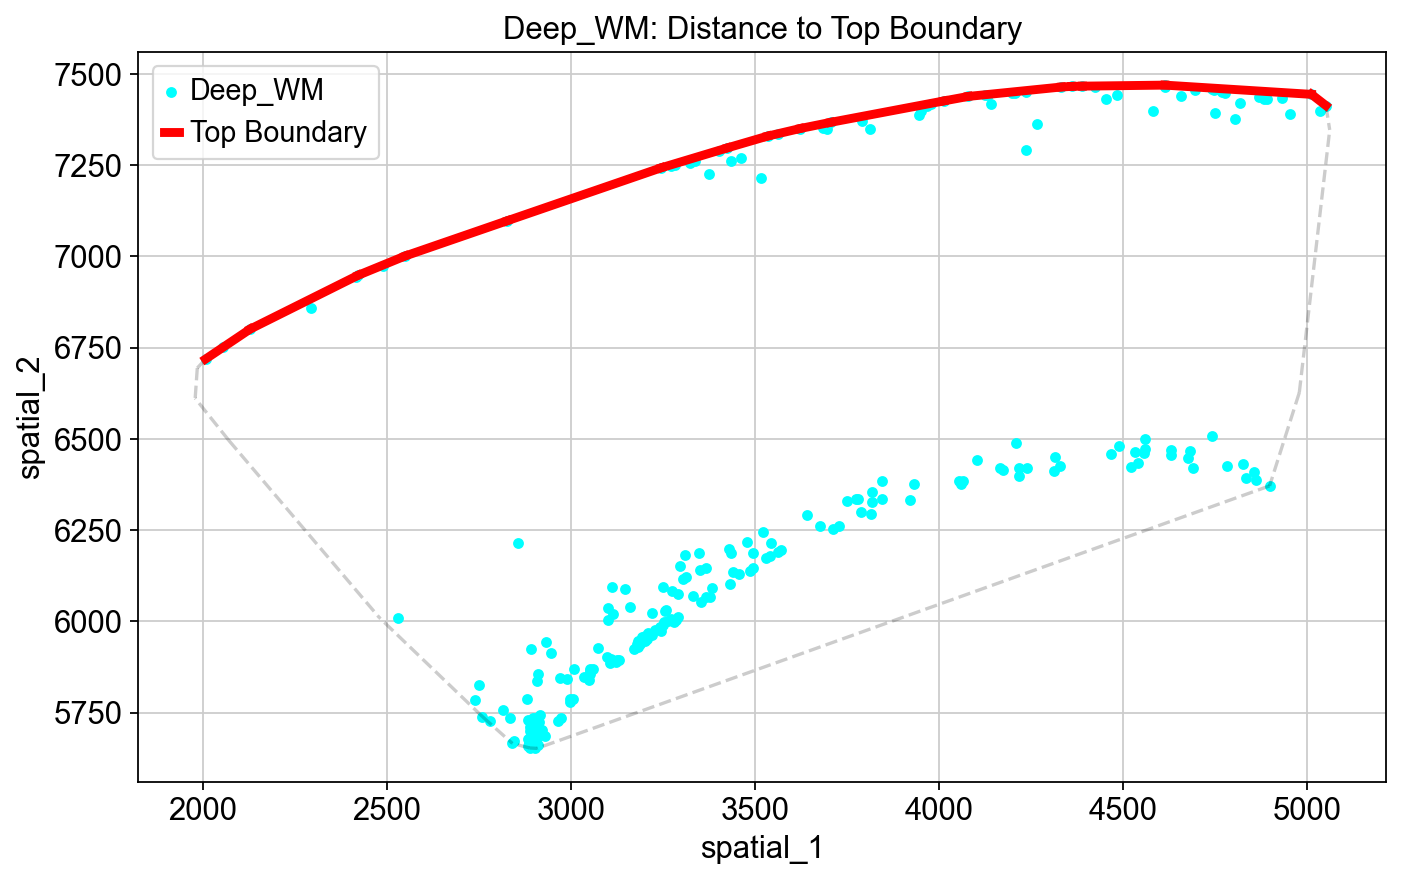

<Figure size 800x480 with 0 Axes>

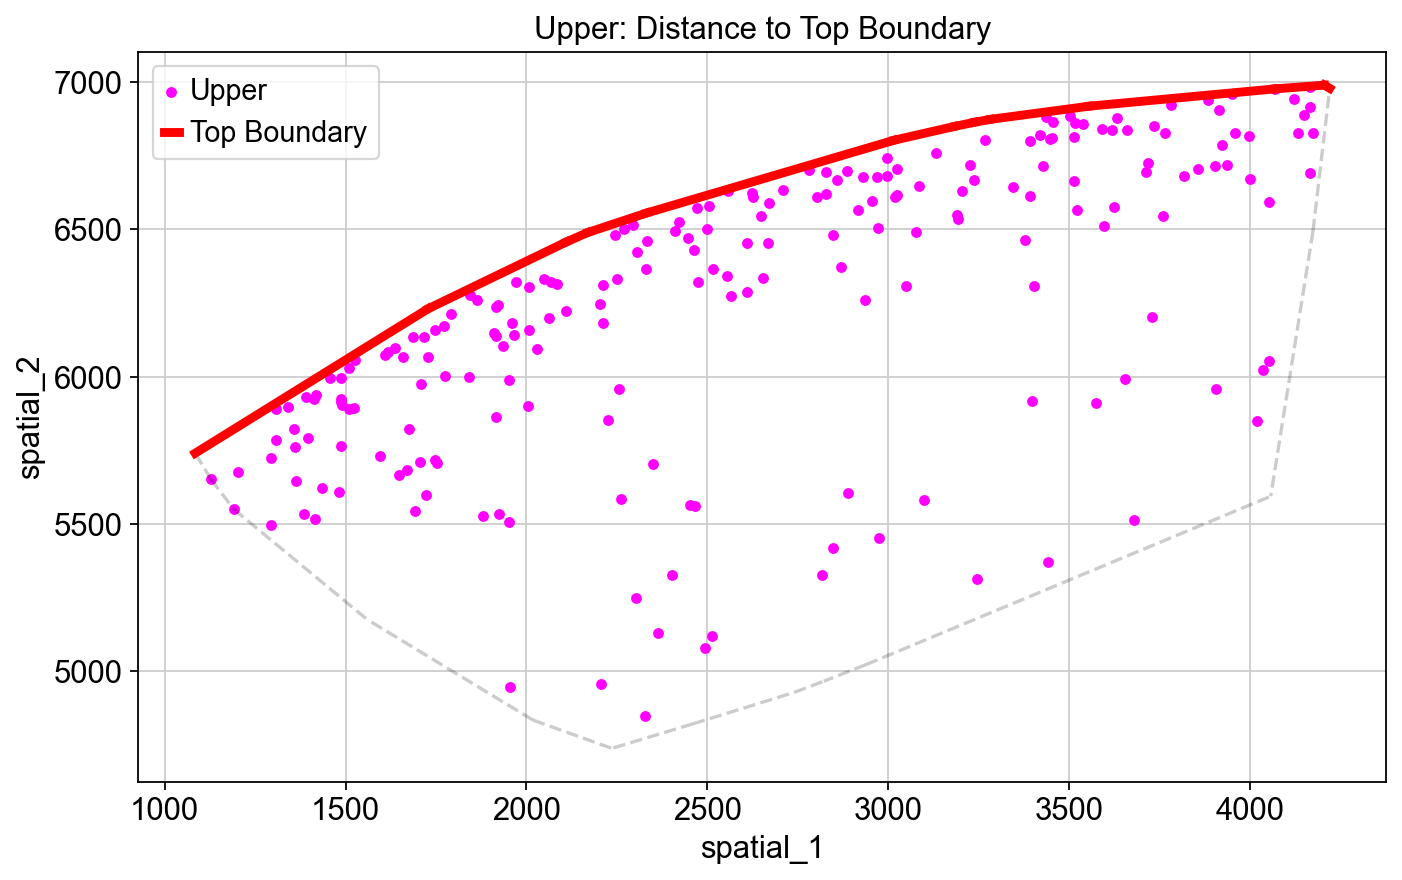

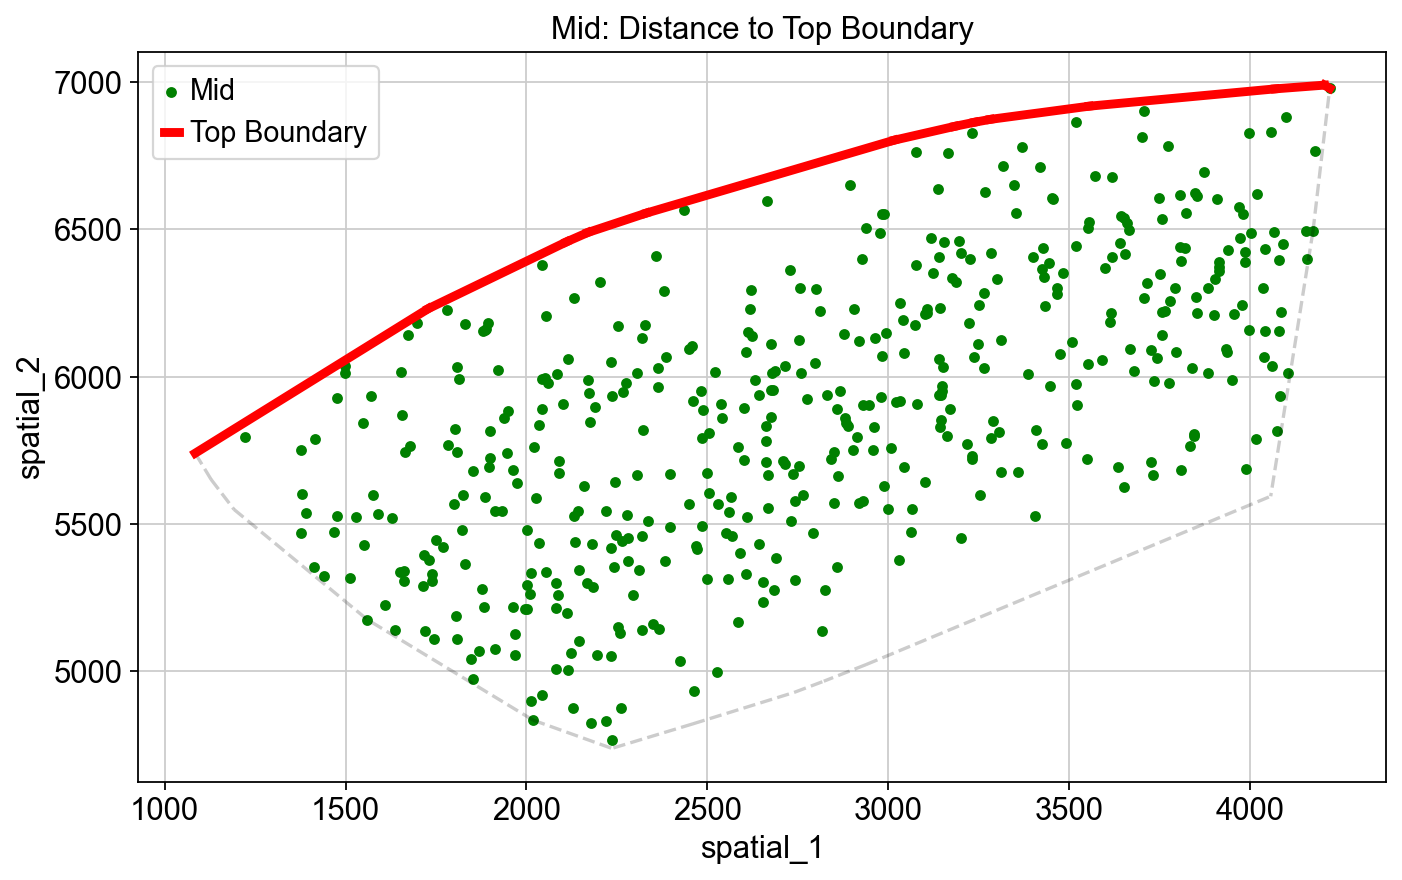

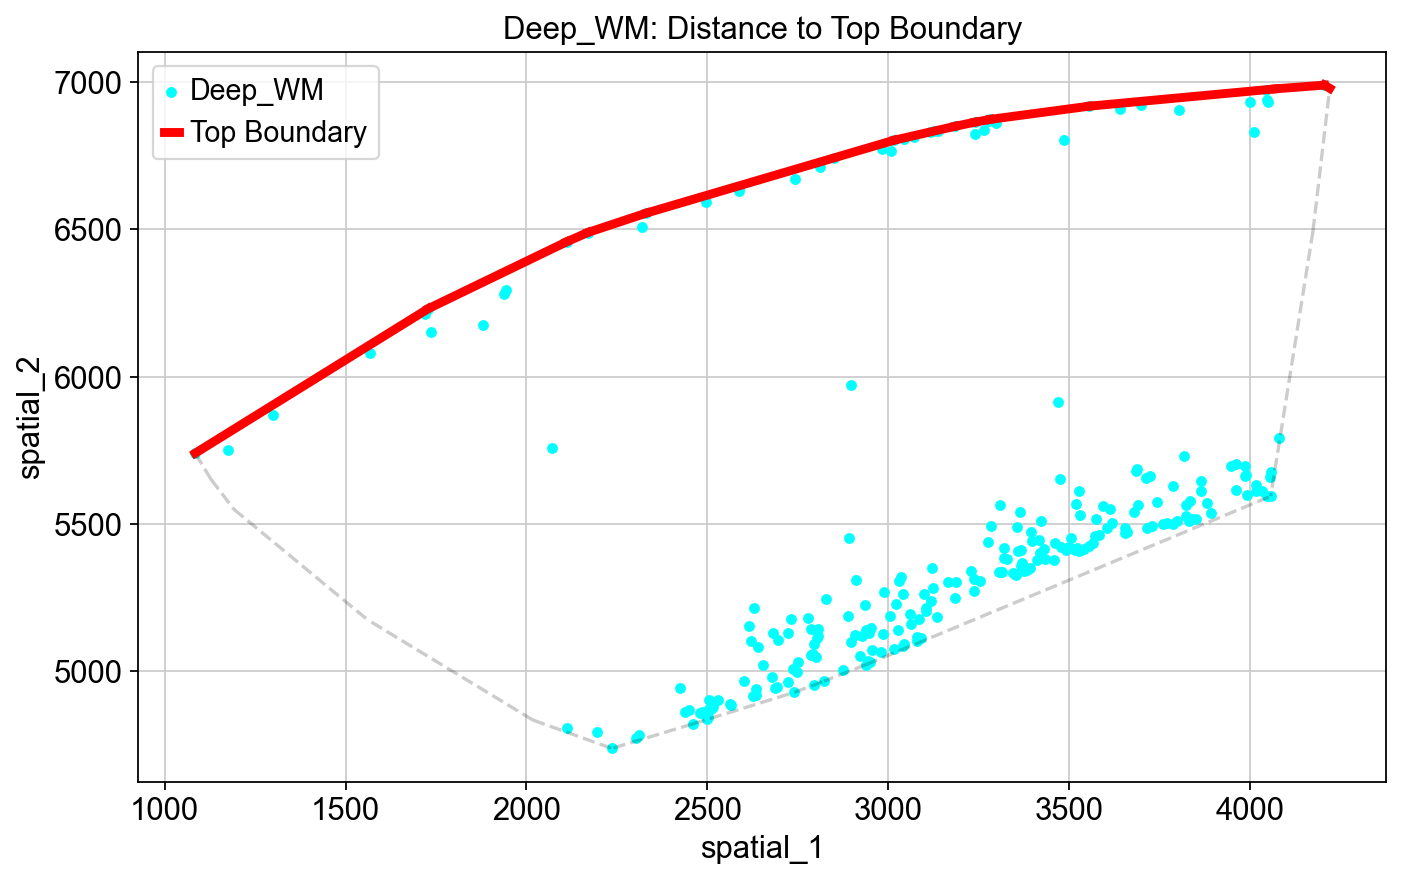

<Figure size 800x480 with 0 Axes>

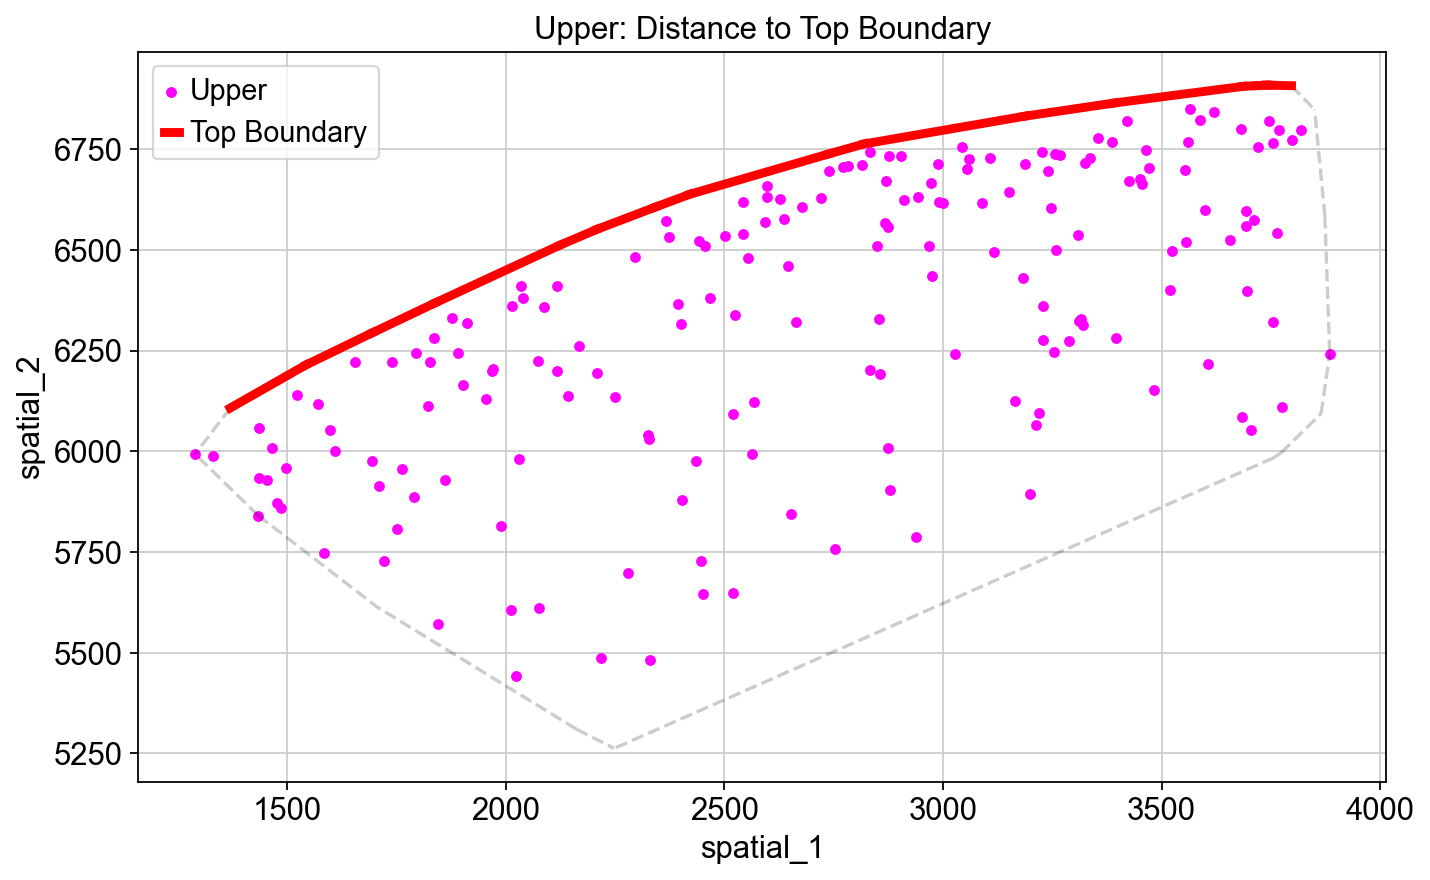

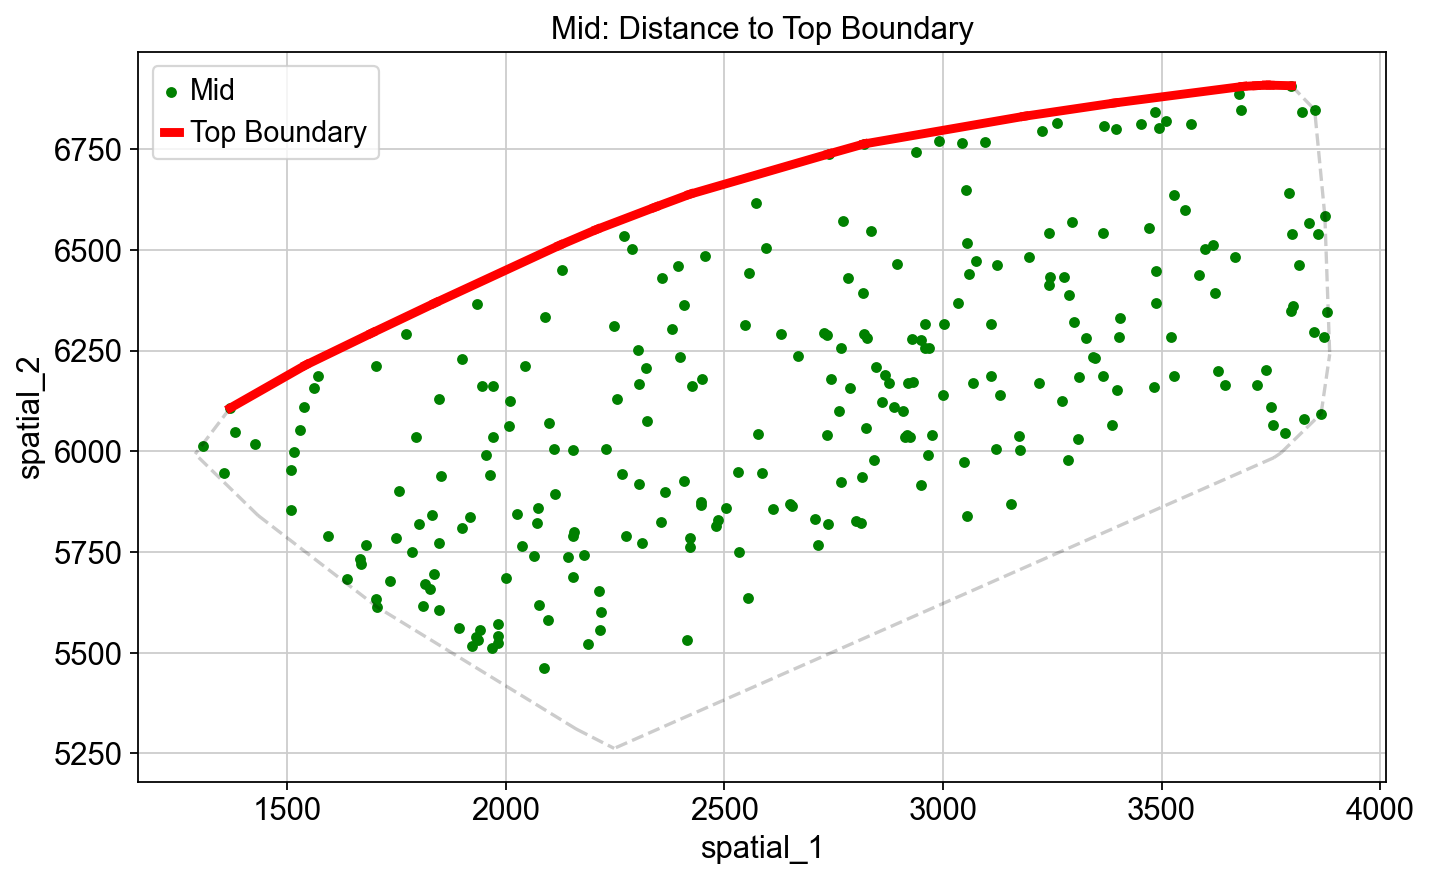

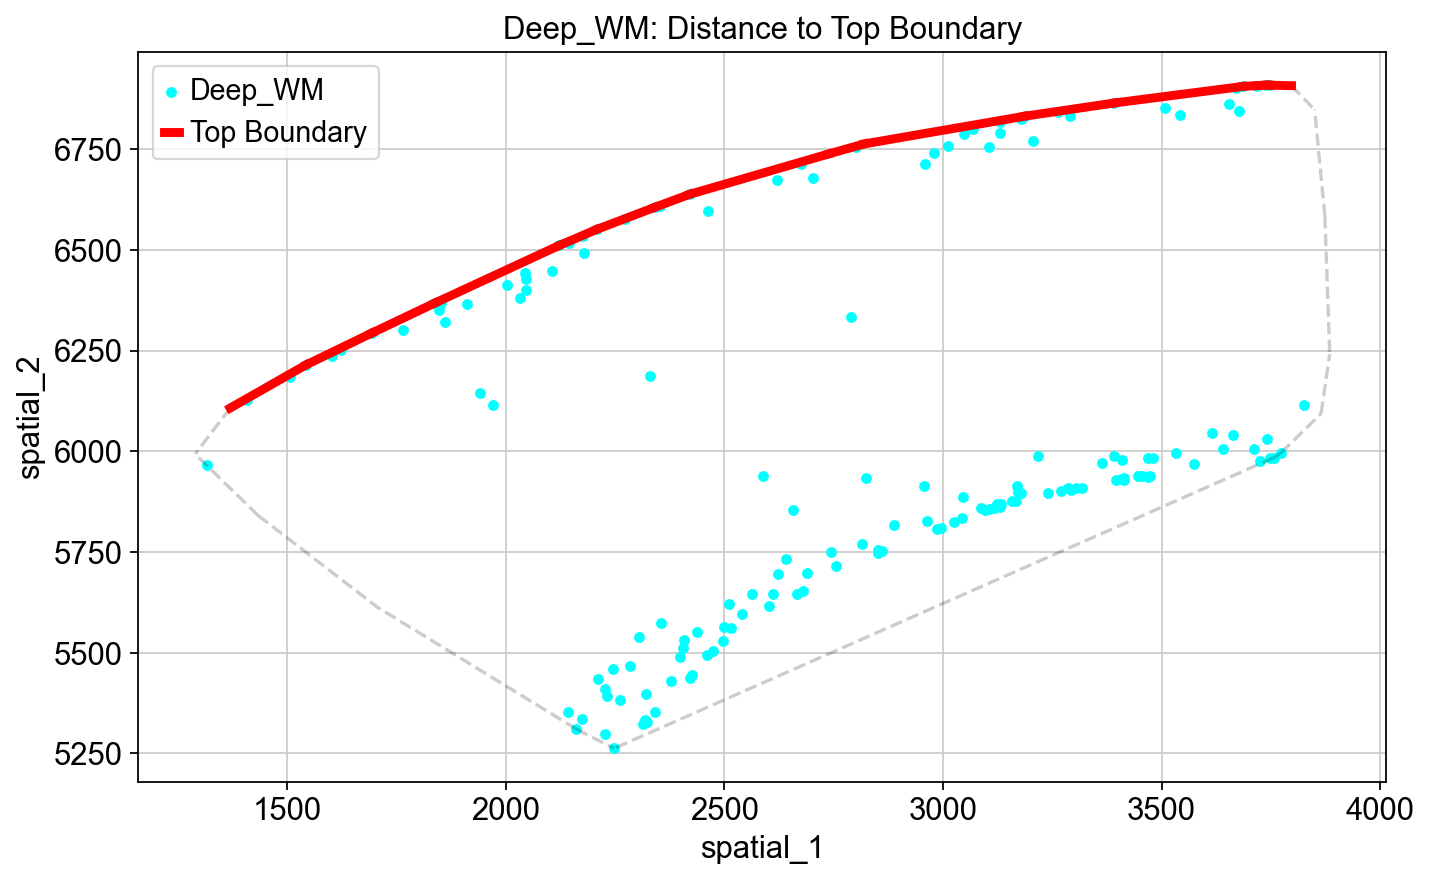

In [58]:
# Dictionary of your samples
samples = {
    "8M": puck_astro_8M,
    "2F": puck_astro_2F,
    "1M": puck_astro_1M,
    "7F": puck_astro_7F
}

# Compute distances for all samples
for name, adata in samples.items():
    samples[name] = plot_spatial_boundary_dist_all_cells(adata, adata_name=name)

In [59]:
# Define function for computing counts of each cell type in 4 equally sized bins spanning pia to corpus callosum
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_binned_proportion(adata, cell_type, obs_col='predicted_type', n_bins=4, adata_name="sample"):
    """
    Plots the proportion of cells of a given type per bin of distance to top
    and returns a DataFrame with counts for each bin.
    
    Parameters:
    - adata: AnnData object
    - cell_type: str, cell type to calculate proportion for
    - obs_col: str, column in adata.obs containing cell types
    - n_bins: int, number of equal-width bins to use
    - adata_name: str, sample identifier (for title/filename)
    
    Returns:
    - df_counts: DataFrame with counts per bin
        columns = ['bin_number', 'total_in_bin', 'count_Upper', 'count_Mid', 'count_Deep_WM']
    """
    # Get distance for all cells
    dist = adata.obs['dist_to_top']
    
    # Boolean mask for the target cell type
    is_target = adata.obs[obs_col] == cell_type
    
    # Define bins
    bins = np.linspace(dist.min(), dist.max(), n_bins + 1)
    
    # Digitize distances into bins
    bin_indices = np.digitize(dist, bins) - 1  # 0-based
    
    # Compute proportions and counts
    proportions = []
    cell_types = ['Upper', 'Mid', 'Deep_WM']
    df_counts = pd.DataFrame(0, index=np.arange(n_bins), columns=['bin_number','total_in_bin'] + [f"count_{ct}" for ct in cell_types])
    df_counts['bin_number'] = np.arange(1, n_bins+1)
    
    for i in range(n_bins):
        in_bin = bin_indices == i
        total_in_bin = np.sum(in_bin)
        df_counts.loc[i, 'total_in_bin'] = total_in_bin
        
        # Count per cell type
        for ct in cell_types:
            df_counts.loc[i, f'count_{ct}'] = np.sum((adata.obs[obs_col] == ct) & in_bin)
        
        # Proportion for the current cell type
        if total_in_bin == 0:
            proportions.append(0)
        else:
            proportions.append(100 * np.sum(is_target & in_bin) / total_in_bin)
    
    return df_counts

In [60]:
# Compute binned subtype counts per sample
samples = {'8M': puck_astro_8M, '2F': puck_astro_2F, '1M': puck_astro_1M, '7F': puck_astro_7F}
cell_types = ['Upper','Mid','Deep_WM']

counts_by_sample = {
    name: {ct: compute_binned_proportion(sample, cell_type=ct, adata_name=name)
           for ct in cell_types}
    for name, sample in samples.items()
}

In [61]:
# Combine samples to get total binned subtype counts per genotype
genotype_map = {'8M': 'WT', '2F': 'WT', '1M': 'KO', '7F': 'KO'}
genotypes = ['WT','KO']

# Prepare empty DataFrames for aggregation
combined_counts = {
    g: pd.DataFrame(0, index=np.arange(4), columns=['bin_number','total_in_bin'] + [f'count_{ct}' for ct in cell_types])
    for g in genotypes
}

for sample_name, ct_dict in counts_by_sample.items():
    g = genotype_map[sample_name]
    # Total counts per bin are the same for each cell type, so we can take the first cell type for total_in_bin
    combined_counts[g]['total_in_bin'] += ct_dict['Upper']['total_in_bin']
    combined_counts[g]['bin_number'] = ct_dict['Upper']['bin_number']
    
    # Sum counts for each cell type
    for ct in cell_types:
        combined_counts[g][f'count_{ct}'] += ct_dict[ct][f'count_{ct}']

In [62]:
# Plot binned subtype counts by genotype
def plot_binned_proportion_by_genotype(combined_counts, cell_type, n_bins=4):
    """
    Plots proportion per bin for a given cell type, aggregated by genotype.
    """
    genotypes = ['WT','KO']
    genotype_colors = {"WT": "dodgerblue", "KO": "crimson"}
    
    x = np.arange(1, n_bins+1)
    width = 0.35  # bar width
    
    plt.figure(figsize=(8,4))
    
    for g_idx, g in enumerate(genotypes):
        df = combined_counts[g]
        proportions = 100 * df[f'count_{cell_type}'] / df['total_in_bin']
        plt.bar(x + g_idx*width, proportions, width=width, color=genotype_colors[g], label=g)
    
    plt.xticks(x + width/2, x)
    plt.xlabel("Bin number", fontsize = 18)
    plt.ylabel(f"% of all astros in bin", fontsize = 18)
    plt.ylim(0, 100)
    plt.title(f"{cell_type}", fontsize = 24)
    plt.tick_params(axis='both', labelsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize = "large")
    plt.tight_layout()
    plt.savefig(f"{parent_dir}/plots/binned_barplot_combined_{cell_type}.png", dpi=300)  # save as PNG
    plt.show()

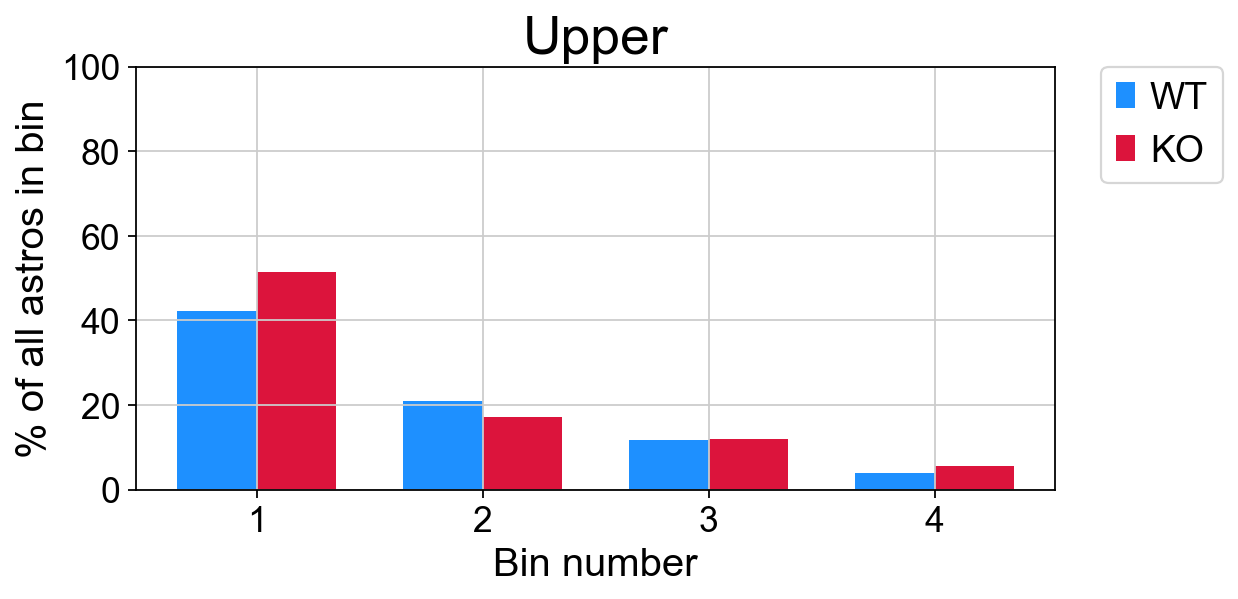

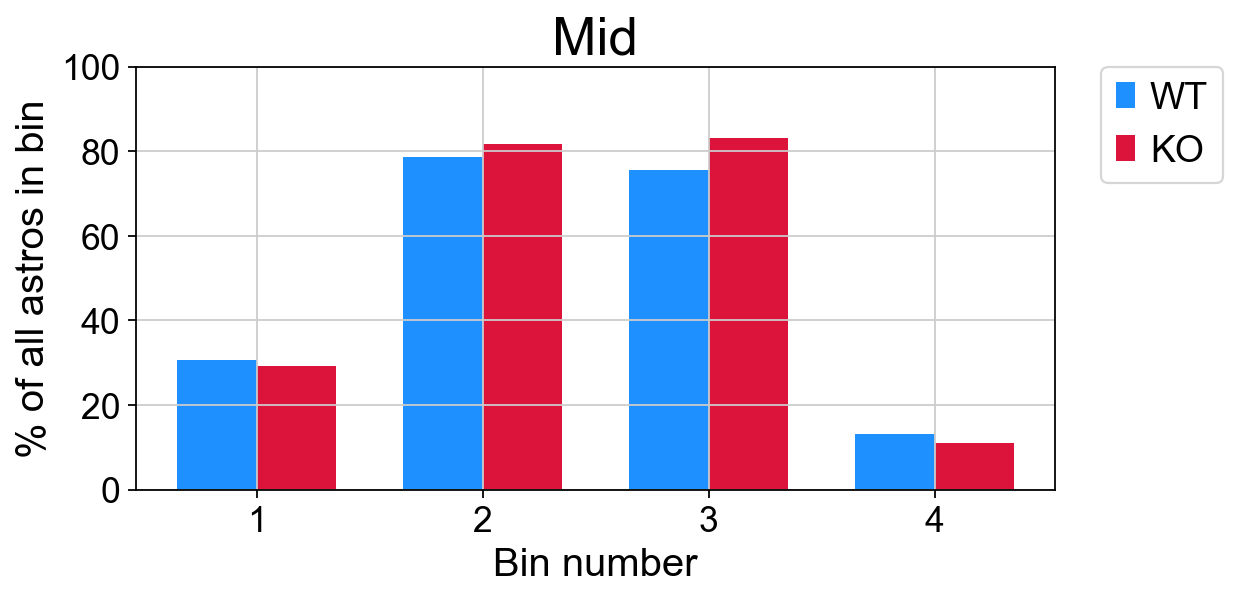

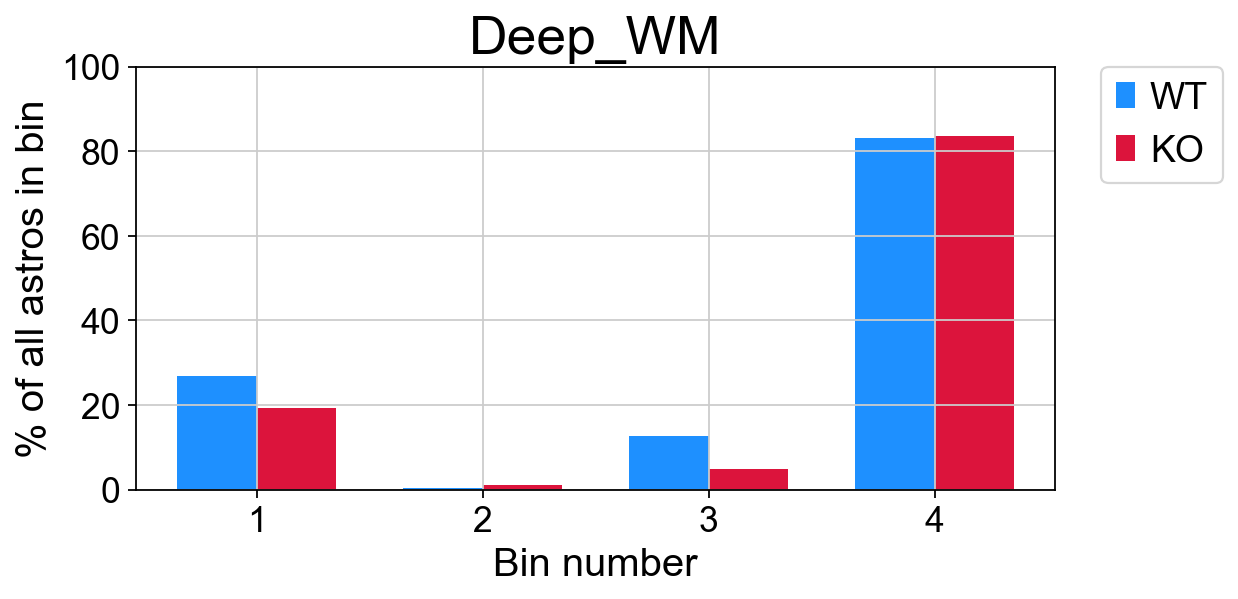

In [63]:
cell_types = ['Upper','Mid','Deep_WM']
for ct in cell_types:
    plot_binned_proportion_by_genotype(combined_counts, cell_type=ct)